In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_rows', 500)

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.pylab import rcParams
import seaborn as sns
rcParams['figure.figsize']=8,5

In [3]:
data_folder = '../data/raw/'

In [4]:
!ls $data_folder

sample_solution.csv  test.csv  train.csv


In [5]:
train_csv = 'train.csv'
test_csv = 'test.csv'
data_folder+train_csv, data_folder+test_csv

('../data/raw/train.csv', '../data/raw/test.csv')

# Exploring the datesets

In [6]:
train_df = pd.read_csv(data_folder+train_csv)
test_df = pd.read_csv(data_folder+test_csv)

train_df.shape, test_df.shape

((2000, 65), (500, 56))

# Data dictionary

In [7]:
def unique_values(df):
    for col in df.columns:
        print(f'---------{col}\n')
        print(df[col].unique())
        print(f'---------END OF SECTION \n')

# EDA on Train

In [8]:
train_df.head()

,Component1_fraction,Component2_fraction,Component3_fraction,Component4_fraction,Component5_fraction,Component1_Property1,Component2_Property1,Component3_Property1,Component4_Property1,Component5_Property1,...,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
0,0.21,0.00,0.42,0.25,0.12,-0.021782,1.981251,0.020036,0.140315,1.032029,...,0.489143,0.607589,0.321670,-1.236055,1.601132,1.384662,0.305850,0.193460,0.580374,-0.762738
1,0.02,0.33,0.19,0.46,0.00,-0.224339,1.148036,-1.107840,0.149533,-0.354000,...,-1.257481,-1.475283,-0.437385,-1.402911,0.147941,-1.143244,-0.439171,-1.379041,-1.280989,-0.503625
2,0.08,0.08,0.18,0.50,0.16,0.457763,0.242591,-0.922492,0.908213,0.972003,...,1.784349,0.450467,0.622687,1.375614,-0.428790,1.161616,0.601289,0.872950,0.660000,2.024576
3,0.25,0.42,0.00,0.07,0.26,-0.577734,-0.930826,0.815284,0.447514,0.455717,...,-0.066422,0.483730,-1.865442,-0.046295,-0.163820,-0.209693,-1.840566,0.300293,-0.351336,-1.551914
4,0.26,0.16,0.08,0.50,0.00,0.120415,0.666268,-0.626934,2.725357,0.392259,...,-0.118913,-1.172398,0.301785,-1.787407,-0.493361,-0.528049,0.286344,-0.265192,0.430513,0.735073


# Casting the data into relevant data types (if any discrepancy is found)

In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 65 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Component1_fraction    2000 non-null   float64
 1   Component2_fraction    2000 non-null   float64
 2   Component3_fraction    2000 non-null   float64
 3   Component4_fraction    2000 non-null   float64
 4   Component5_fraction    2000 non-null   float64
 5   Component1_Property1   2000 non-null   float64
 6   Component2_Property1   2000 non-null   float64
 7   Component3_Property1   2000 non-null   float64
 8   Component4_Property1   2000 non-null   float64
 9   Component5_Property1   2000 non-null   float64
 10  Component1_Property2   2000 non-null   float64
 11  Component2_Property2   2000 non-null   float64
 12  Component3_Property2   2000 non-null   float64
 13  Component4_Property2   2000 non-null   float64
 14  Component5_Property2   2000 non-null   float64
 15  Comp

* All the columns have the correct data types
* There seems to be a need of an ID column for the dataset.

## Observations until now:

* the sum of component fractions should be equal to 1 as it is vol % of each base component in the whole blend.

# The descriptics statistics for all numerical columns


In [17]:
target_cols = [ col for col in train_df.columns if "BlendProperty" in col]
target_cols, len(target_cols)==10

(['BlendProperty1',
  'BlendProperty2',
  'BlendProperty3',
  'BlendProperty4',
  'BlendProperty5',
  'BlendProperty6',
  'BlendProperty7',
  'BlendProperty8',
  'BlendProperty9',
  'BlendProperty10'],
 True)

In [10]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Component1_fraction,2000.0,0.180690,0.163200,0.000000,0.030000,0.140000,0.290000,0.500000
Component2_fraction,2000.0,0.182910,0.163704,0.000000,0.040000,0.150000,0.300000,0.500000
Component3_fraction,2000.0,0.179820,0.166283,0.000000,0.020000,0.140000,0.290000,0.500000
Component4_fraction,2000.0,0.342090,0.141119,0.010000,0.220000,0.350000,0.500000,0.500000
Component5_fraction,2000.0,0.114490,0.080219,0.000000,0.050000,0.120000,0.180000,0.290000
Component1_Property1,2000.0,0.000245,0.999423,-2.943737,-0.694658,0.011977,0.685717,2.981146
Component2_Property1,2000.0,-0.017319,1.006409,-1.718895,-0.765154,-0.030235,0.653960,3.051090
Component3_Property1,2000.0,0.001703,0.998859,-3.008683,-0.701948,0.021335,0.673125,2.868901
Component4_Property1,2000.0,-0.004653,1.006902,-3.029468,-0.693361,0.016774,0.659227,2.982258
Component5_Property1,2000.0,-0.018256,1.009294,-3.572440,-0.713149,0.194936,1.032029,1.032029


In [18]:
train_df[target_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
BlendProperty1,2000.0,-0.016879,0.993787,-2.550897,-0.766128,-0.021089,0.714763,2.856588
BlendProperty2,2000.0,-0.002076,1.004512,-3.079759,-0.735109,0.001684,0.723807,2.769156
BlendProperty3,2000.0,-0.014351,0.999360,-3.041624,-0.624235,0.146135,0.727597,1.638646
BlendProperty4,2000.0,-0.006068,1.009176,-2.835701,-0.783547,-0.028158,0.664659,3.769643
BlendProperty5,2000.0,-0.015249,0.986480,-1.730111,-0.683165,-0.250650,0.358701,3.600439
BlendProperty6,2000.0,-0.003497,1.009126,-2.808210,-0.697379,-0.011649,0.695182,3.433292
BlendProperty7,2000.0,-0.013568,1.000613,-2.994571,-0.622453,0.133470,0.704130,3.293228
BlendProperty8,2000.0,-0.017236,0.998759,-3.621080,-0.725564,-0.001548,0.684894,3.340657
BlendProperty9,2000.0,-0.001507,1.001096,-3.292727,-0.702384,-0.002604,0.706084,3.276199
BlendProperty10,2000.0,-0.001795,0.990433,-2.476429,-0.733653,-0.010459,0.693839,2.708703


array([[<Axes: title={'center': 'BlendProperty1'}>,
        <Axes: title={'center': 'BlendProperty2'}>,
        <Axes: title={'center': 'BlendProperty3'}>],
       [<Axes: title={'center': 'BlendProperty4'}>,
        <Axes: title={'center': 'BlendProperty5'}>,
        <Axes: title={'center': 'BlendProperty6'}>],
       [<Axes: title={'center': 'BlendProperty7'}>,
        <Axes: title={'center': 'BlendProperty8'}>,
        <Axes: title={'center': 'BlendProperty9'}>],
       [<Axes: title={'center': 'BlendProperty10'}>, <Axes: >, <Axes: >]],
      dtype=object)

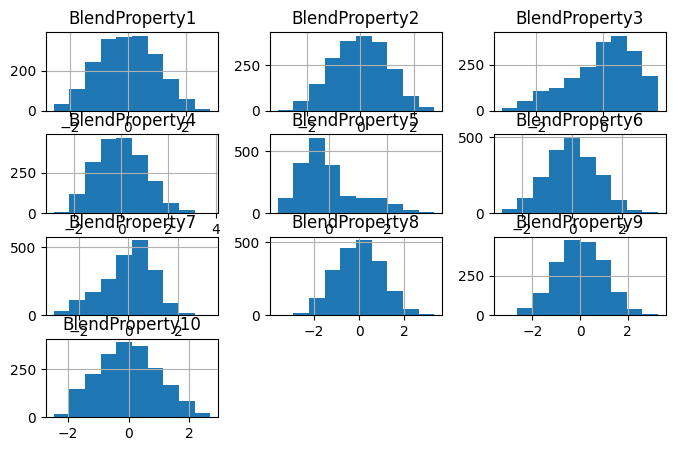

In [12]:
train_df[target_cols].hist()

* `Blendproperties 3 and 8` are bit `skewed`. Others are somewhat following the normal distribution.

<Axes: ylabel='Density'>

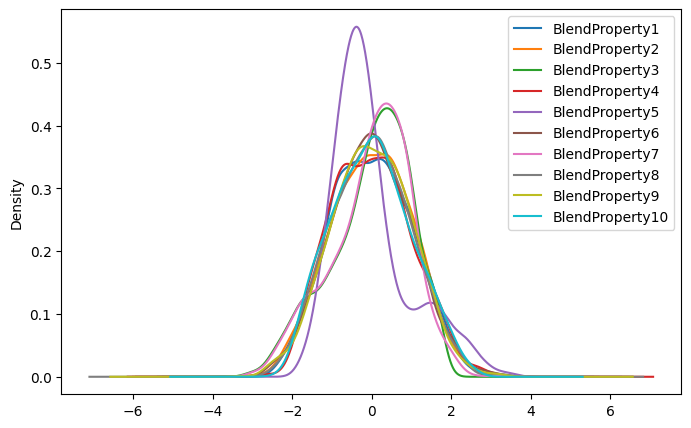

In [13]:
train_df[target_cols].plot.density()

## Distribution in features

In [14]:
fraction_cols = [col for col in train_df.columns if 'fraction' in col]
property_cols = [col for col in train_df.columns if 'Property' in col and 'Blend' not in col]

<Axes: ylabel='Density'>

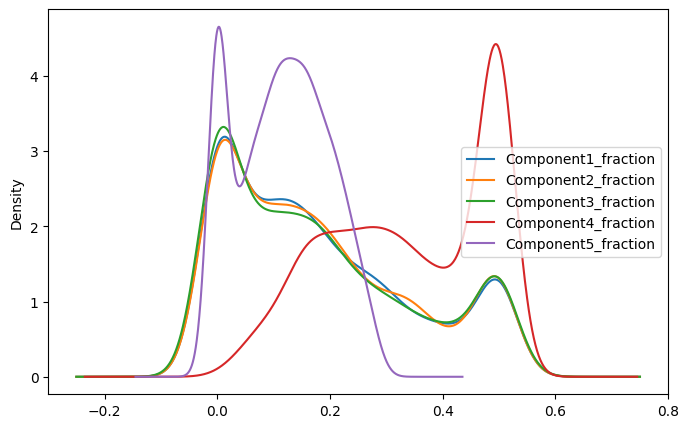

In [15]:
train_df[fraction_cols].plot.density()

<Axes: ylabel='Density'>

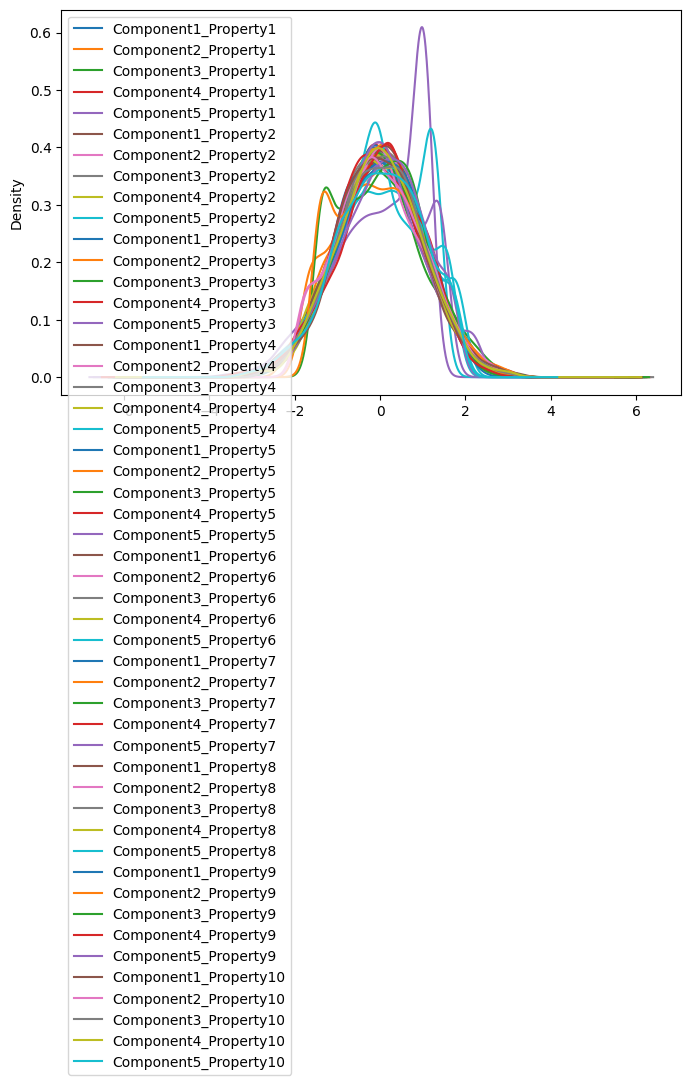

In [16]:
train_df[property_cols].plot.density()

## Correlation Heatmap


In [17]:
len(train_df.columns),train_df.columns

(65,
 Index(['Component1_fraction', 'Component2_fraction', 'Component3_fraction',
        'Component4_fraction', 'Component5_fraction', 'Component1_Property1',
        'Component2_Property1', 'Component3_Property1', 'Component4_Property1',
        'Component5_Property1', 'Component1_Property2', 'Component2_Property2',
        'Component3_Property2', 'Component4_Property2', 'Component5_Property2',
        'Component1_Property3', 'Component2_Property3', 'Component3_Property3',
        'Component4_Property3', 'Component5_Property3', 'Component1_Property4',
        'Component2_Property4', 'Component3_Property4', 'Component4_Property4',
        'Component5_Property4', 'Component1_Property5', 'Component2_Property5',
        'Component3_Property5', 'Component4_Property5', 'Component5_Property5',
        'Component1_Property6', 'Component2_Property6', 'Component3_Property6',
        'Component4_Property6', 'Component5_Property6', 'Component1_Property7',
        'Component2_Property7', 'Compone

In [18]:
corr_matrix = train_df.corr()

<Axes: >

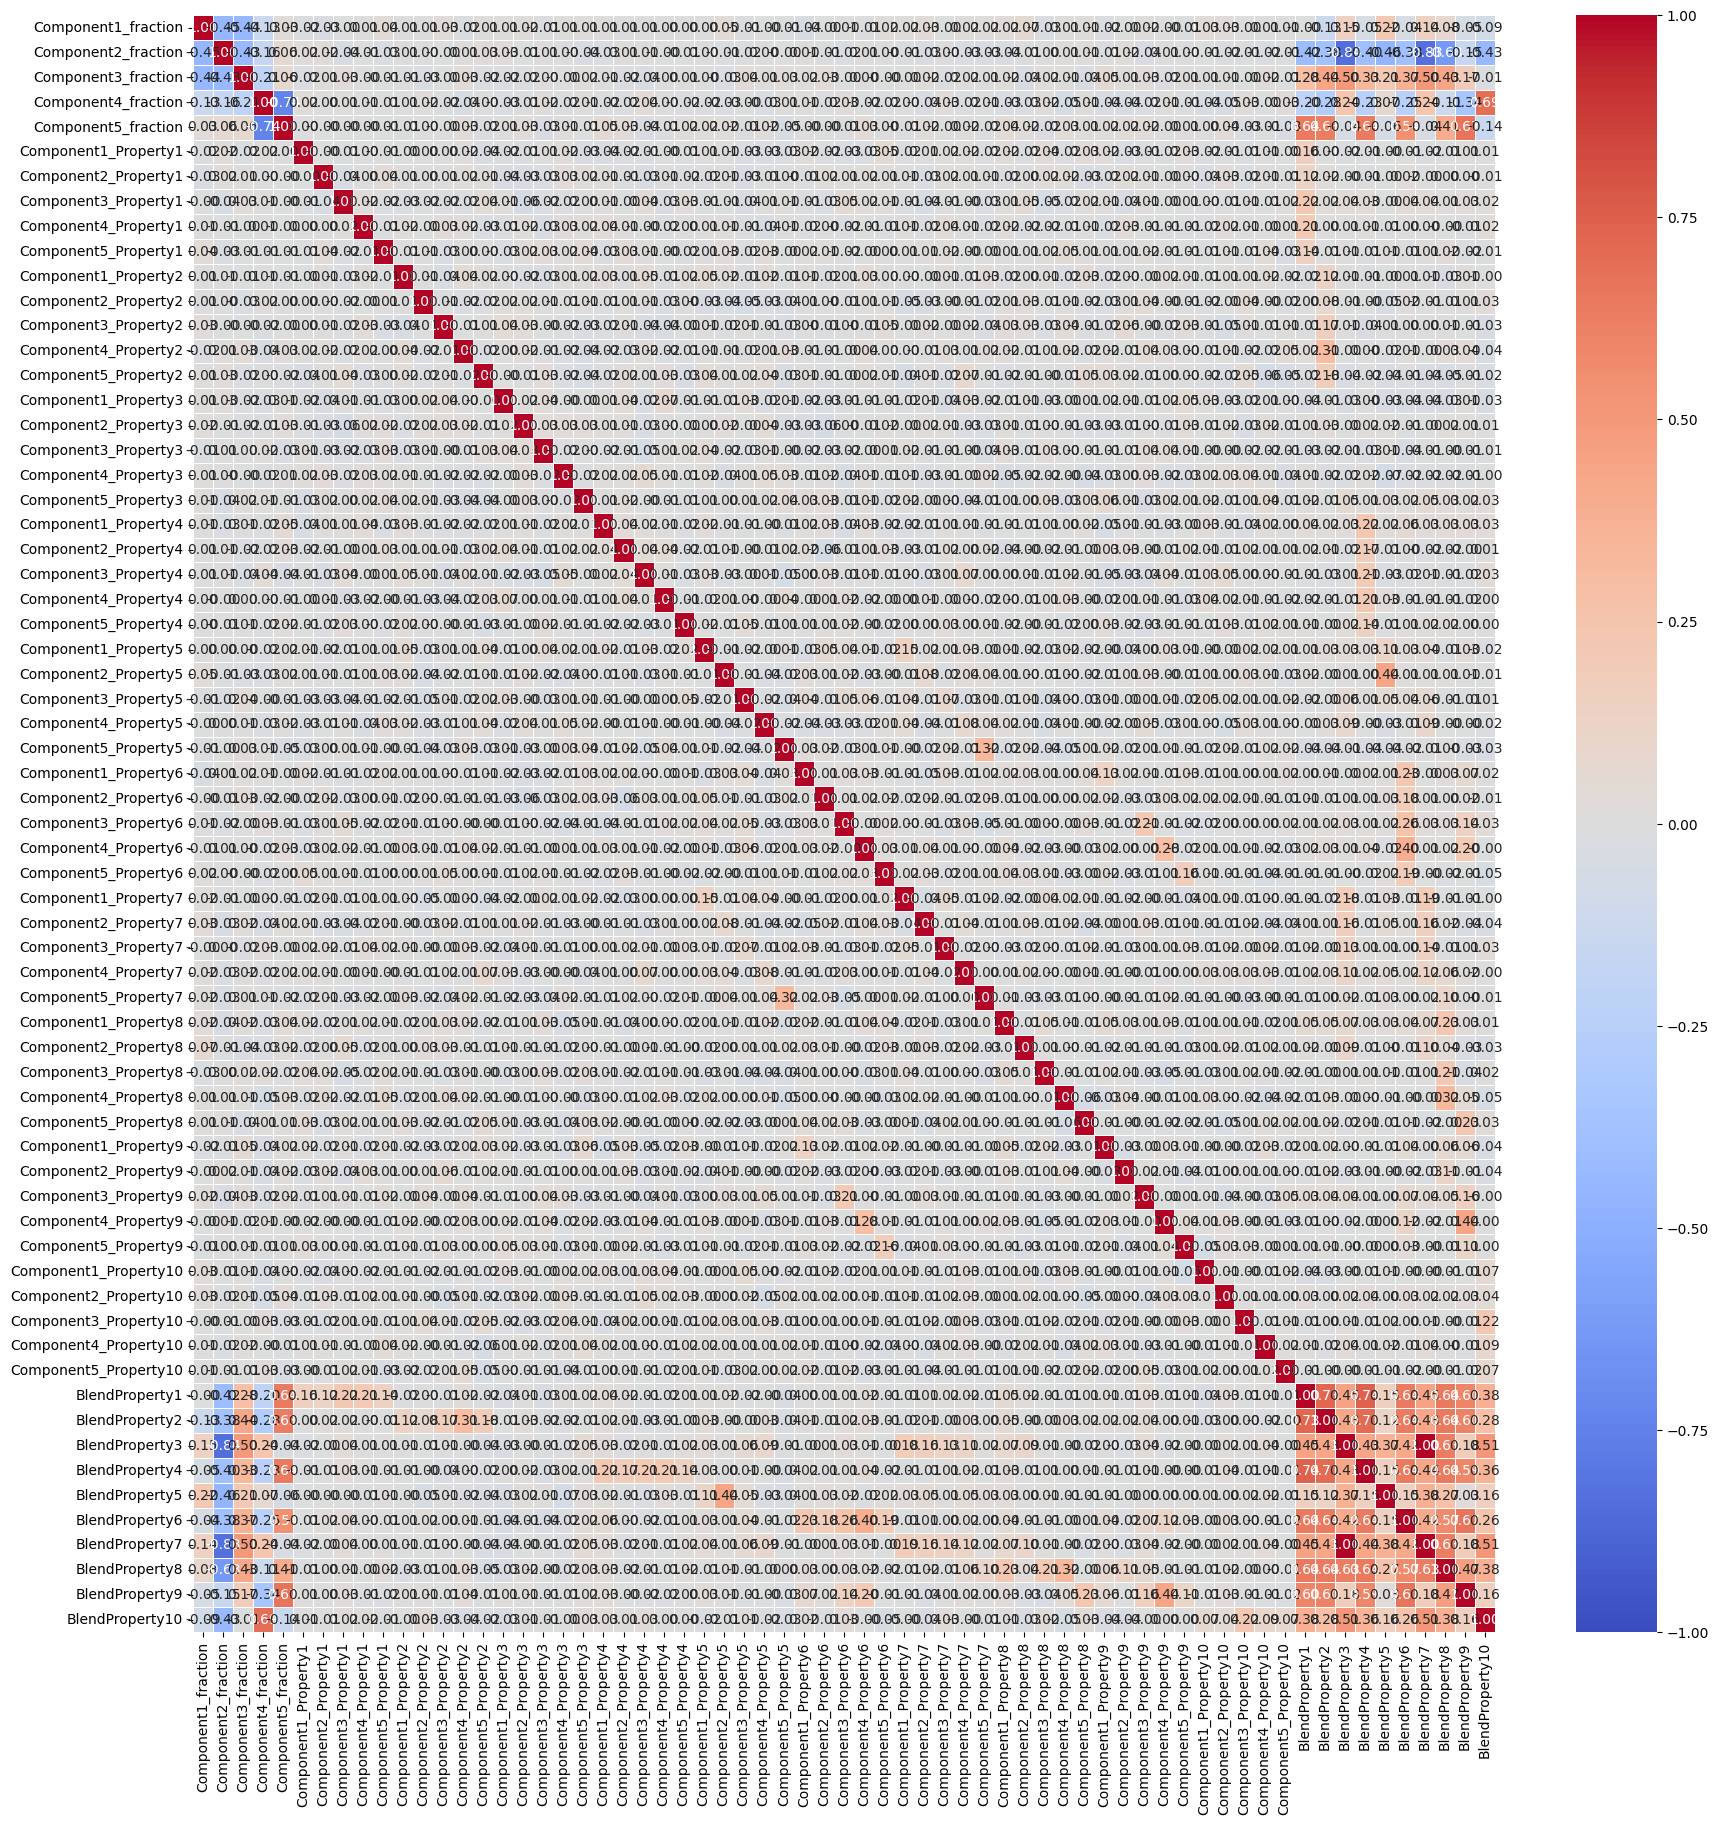

In [21]:
plt.figure(figsize=(21, 21))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f', 
            linewidths=0.5, 
            vmin=-1, vmax=1,
           # center = 0
           )

<Axes: >

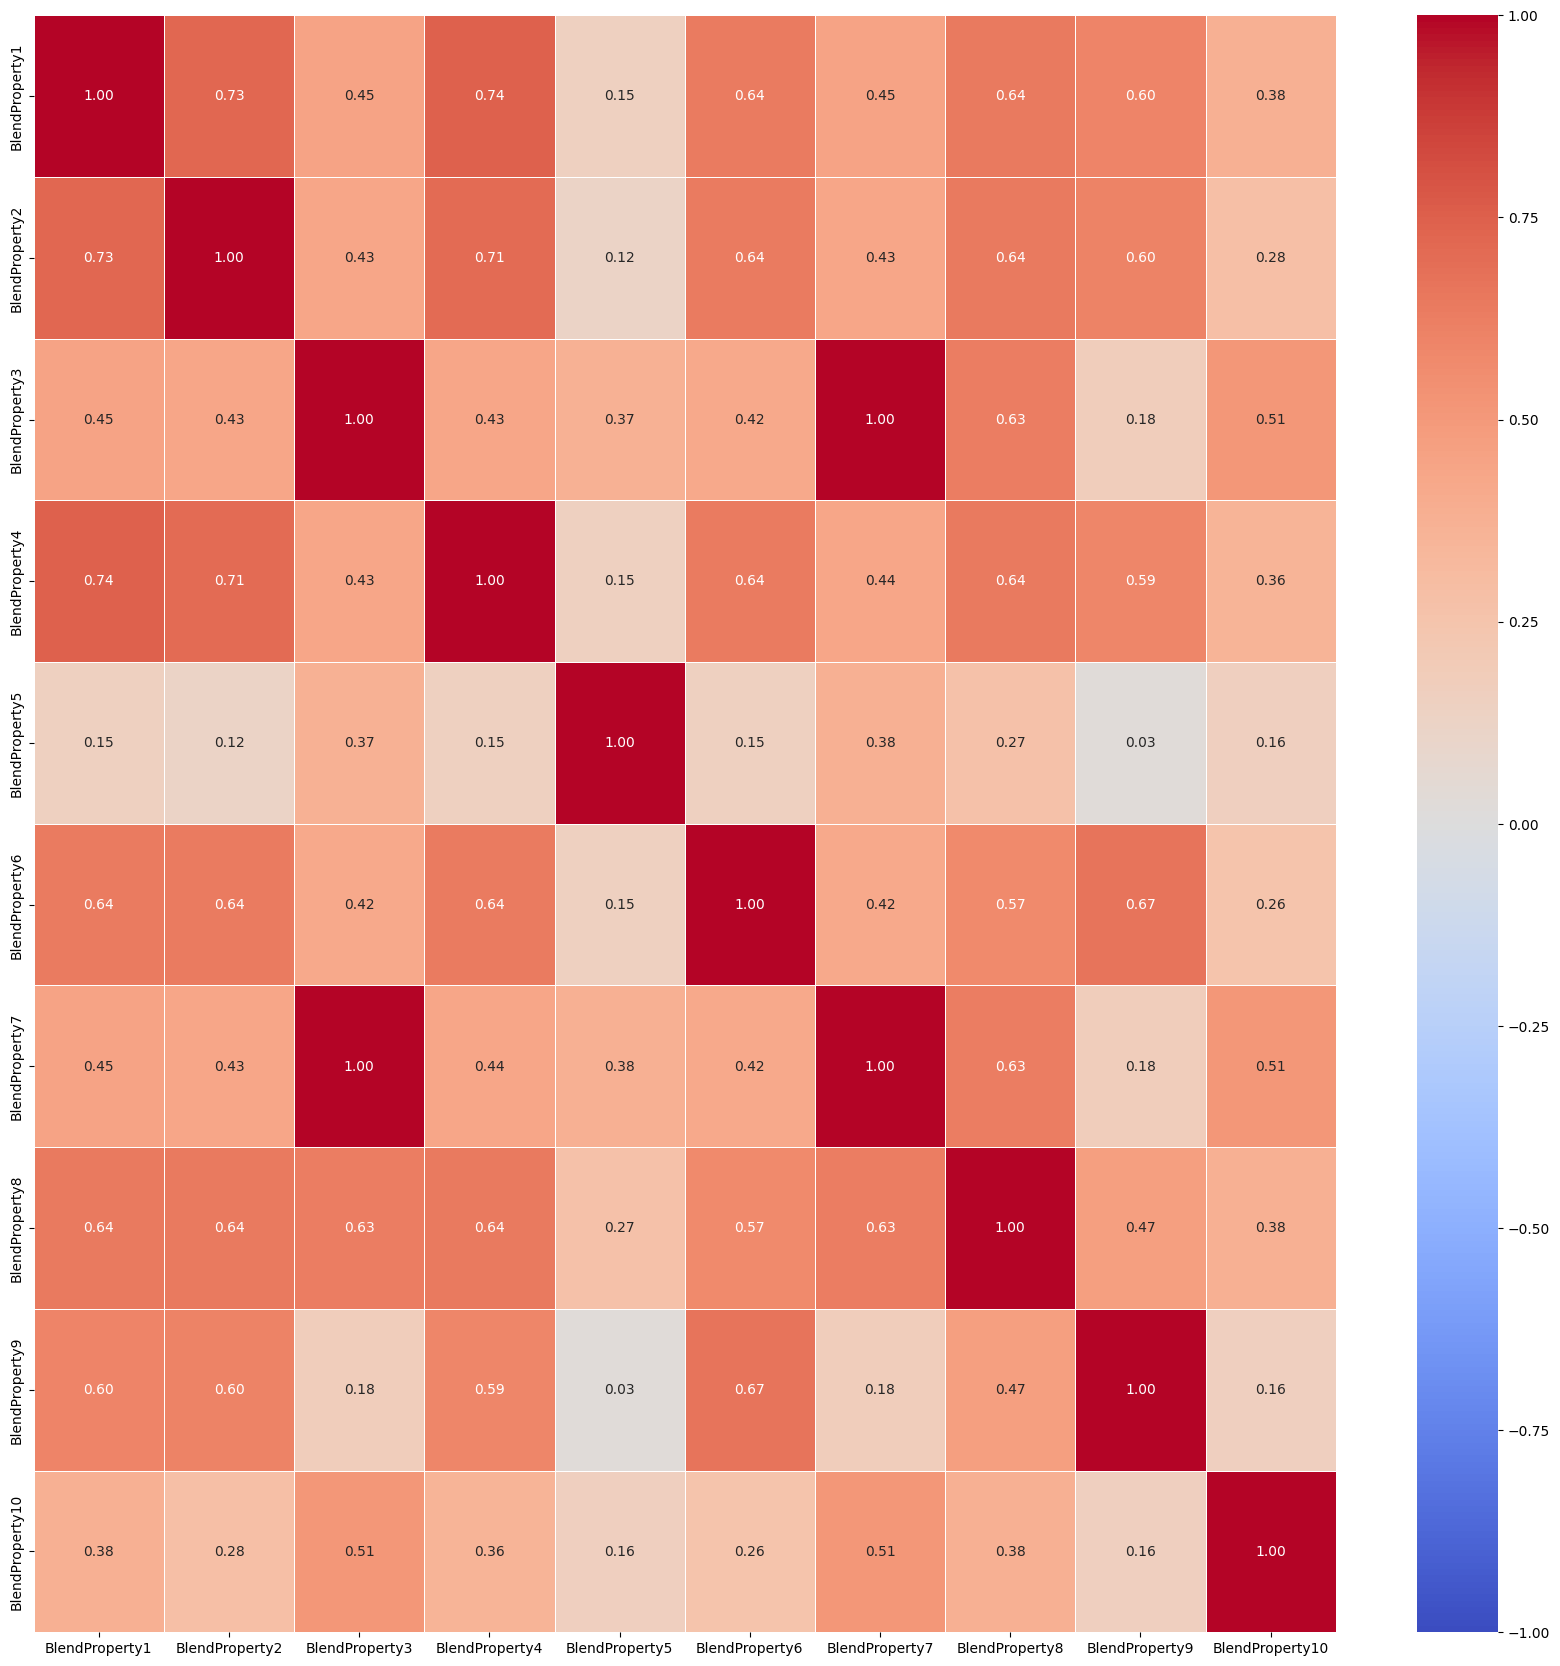

In [23]:
target_corr_matrix = train_df[target_cols].corr()
plt.figure(figsize=(21, 21))
sns.heatmap(target_corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f', 
            linewidths=0.5, 
            vmin=-1, vmax=1,
           # center = 0
           )

## Correlation between features and targets

In [24]:
feature_cols = [col for col in train_df.columns if col not in target_cols]

In [30]:
corr_matrix = train_df[feature_cols + target_cols].corr()

In [34]:
# corr_features_targets = corr_matrix.loc[target_cols, feature_cols]
corr_features_targets = corr_matrix.loc[feature_cols, target_cols]

In [35]:
corr_features_targets

,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
Component1_fraction,-0.002922,-0.132811,0.146851,-0.051559,0.215086,-0.042236,0.138072,0.084148,-0.052030,-0.085037
Component2_fraction,-0.421138,-0.376133,-0.838017,-0.396772,-0.461797,-0.384576,-0.832276,-0.629629,-0.152599,-0.433511
Component3_fraction,0.282358,0.436292,0.497568,0.331242,0.214809,0.367638,0.501855,0.434826,0.172820,-0.011964
Component4_fraction,-0.203952,-0.282413,0.239268,-0.234551,0.065840,-0.245710,0.235021,-0.109528,-0.344702,0.694838
Component5_fraction,0.638858,0.630209,-0.040909,0.640581,-0.056278,0.540913,-0.036182,0.405040,0.665416,-0.139863
Component1_Property1,0.161641,0.001764,-0.015975,-0.014899,-0.003722,-0.005003,-0.017644,-0.008279,0.012378,0.006491
Component2_Property1,0.117614,0.018618,-0.004799,-0.009232,-0.001995,0.022238,-0.004740,0.002319,0.001914,-0.012579
Component3_Property1,0.224167,0.018140,0.041233,0.031593,-0.003134,0.038941,0.038188,0.012545,0.027745,0.018745
Component4_Property1,0.209411,0.002265,0.005495,0.008817,-0.012346,0.001648,0.003800,-0.001194,-0.008291,0.018491
Component5_Property1,0.141028,-0.006494,0.011739,-0.012257,0.012005,-0.007983,0.008416,0.024566,-0.017609,-0.013758


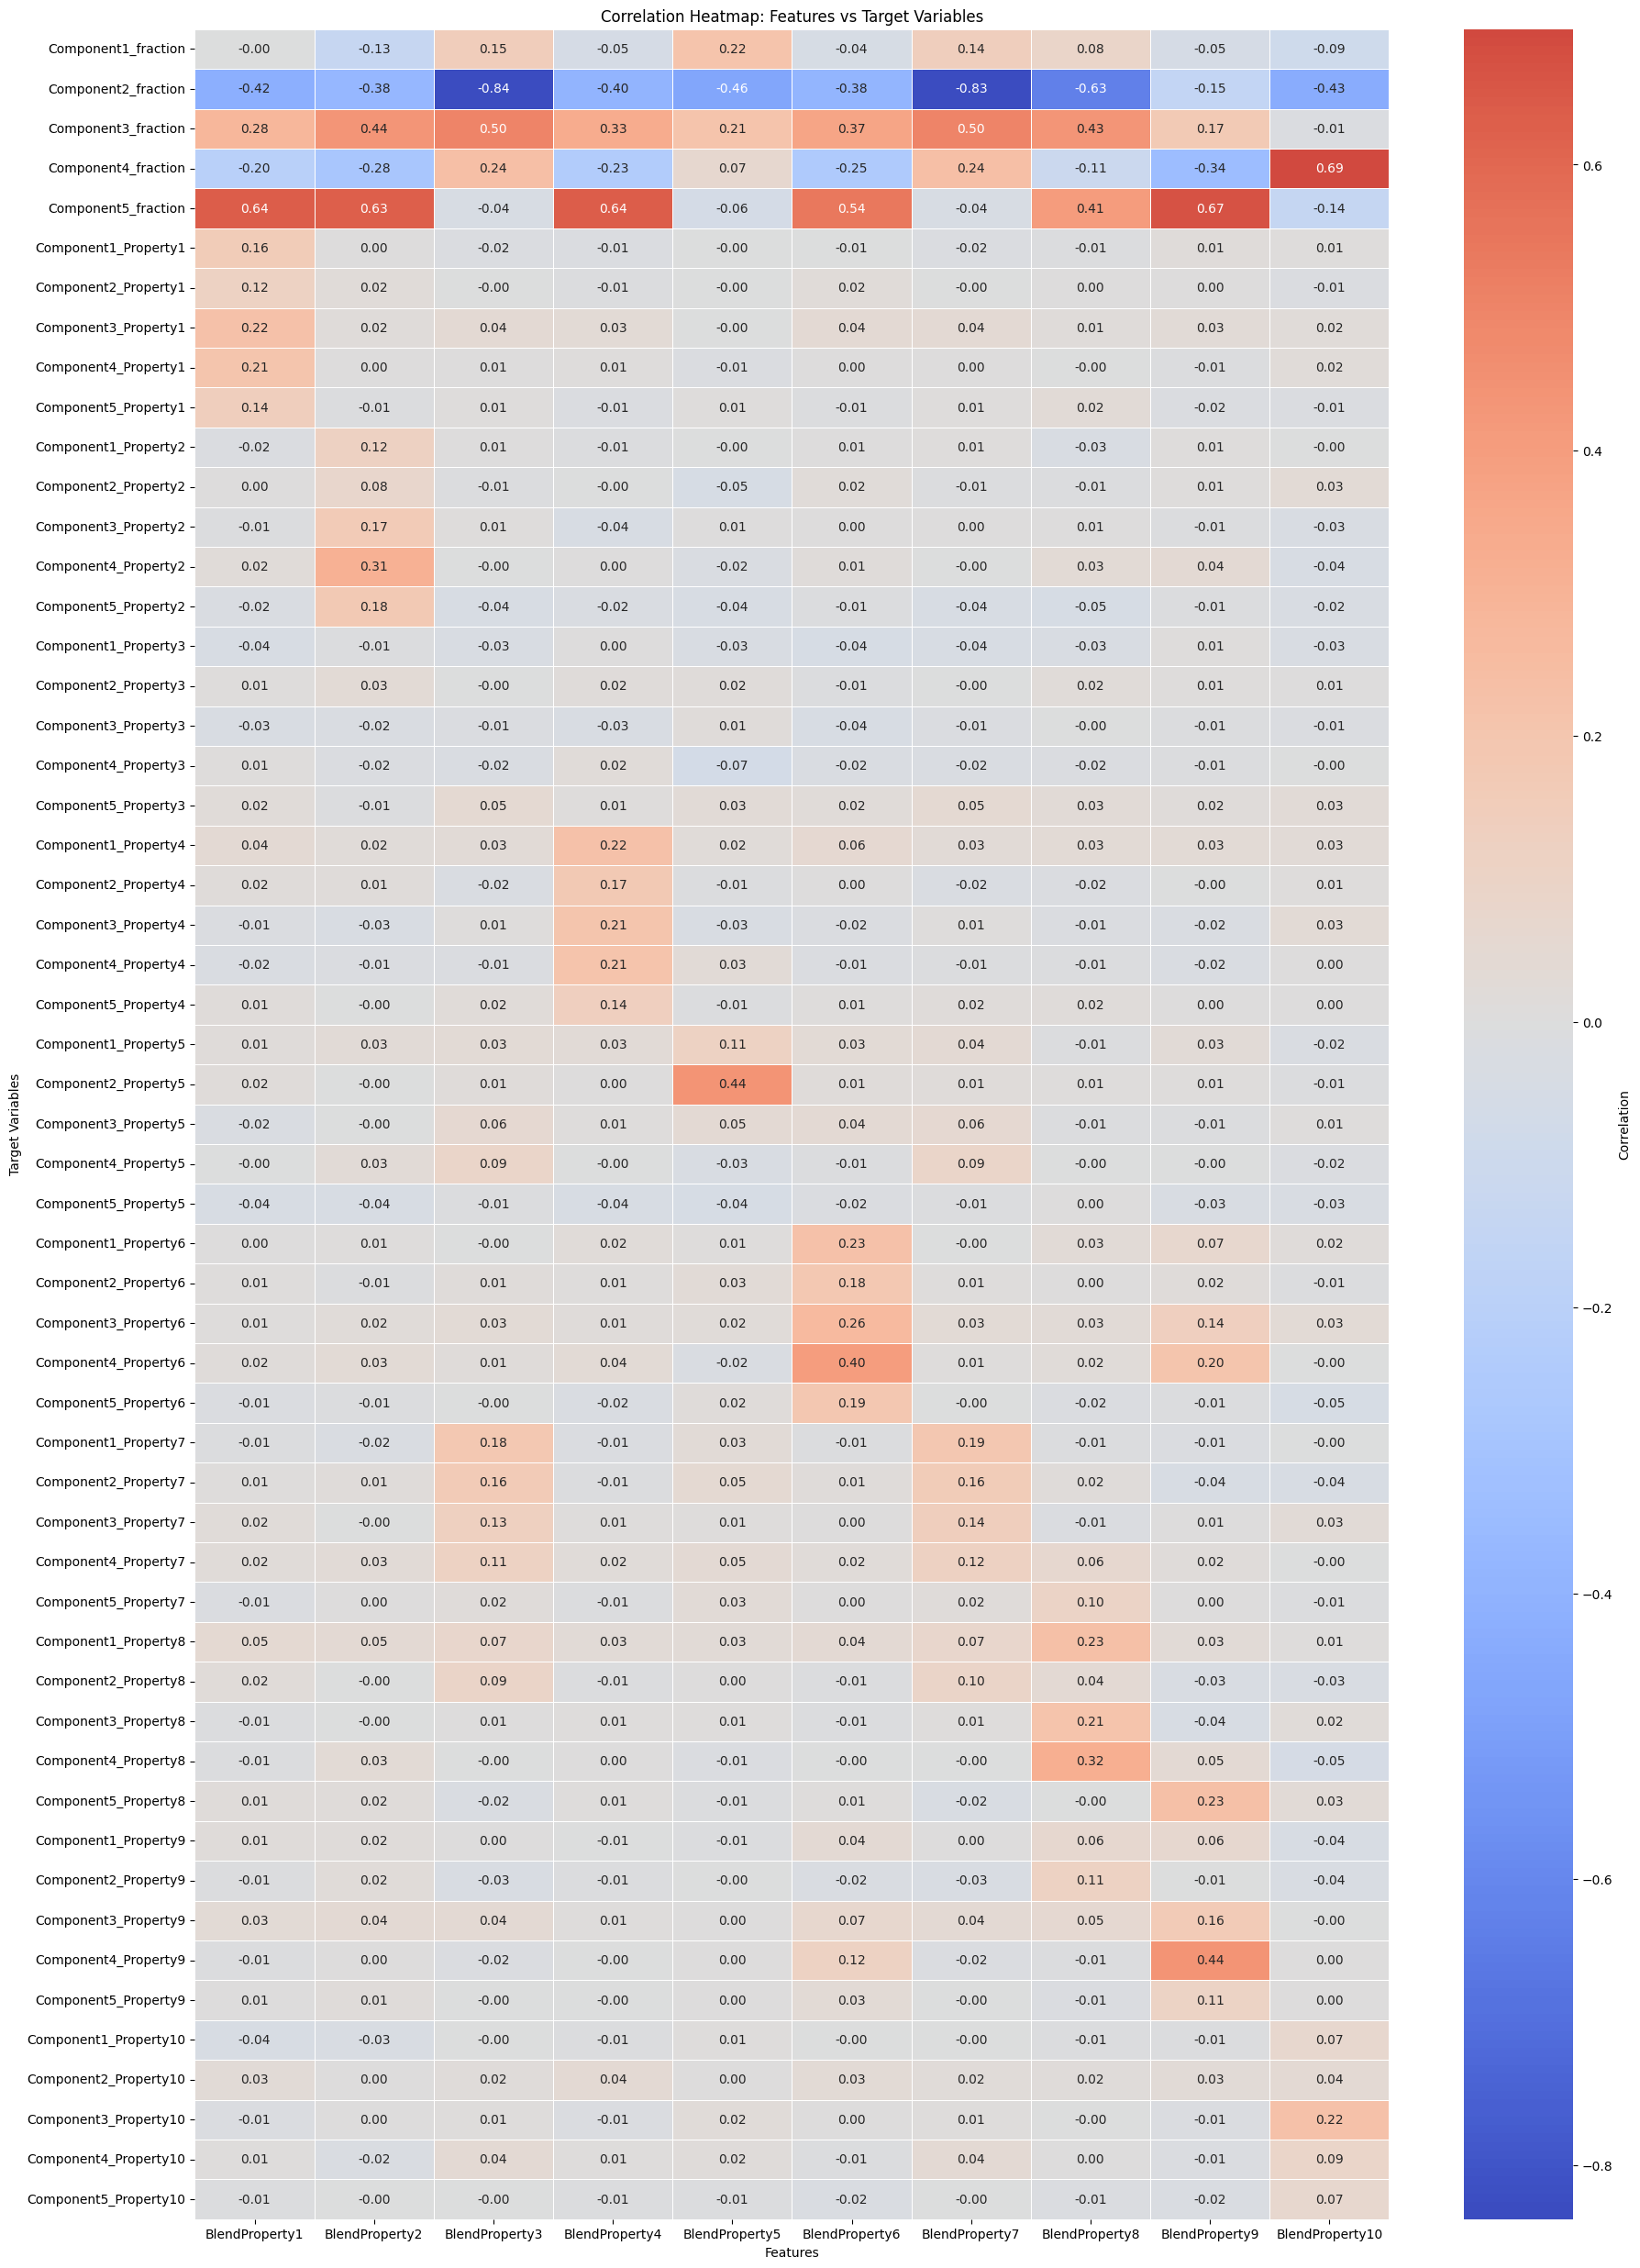

In [41]:
plt.figure(figsize=(21, 31))  # Adjust size as needed
sns.heatmap(corr_features_targets, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap: Features vs Target Variables')
plt.xlabel('Features')
plt.ylabel('Target Variables')

# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()

plt.show()

* This is a rich data vis which can give a immense amount of info about the fuel blended together.